## Importing libraries



In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys


DATA_DIR = Path.cwd() / 'data'
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Expected a data folder at {DATA_DIR}')

print(f'Using data directory: {DATA_DIR.resolve()}')


Using data directory: C:\Users\Gaurob\Desktop\Modularization_Practise\data


In [2]:
def ensure_package(package_name: str, import_name=None) -> None:
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

ensure_package('optuna')
ensure_package('xgboost')

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.feature_selection import mutual_info_regression



C:\Users\Gaurob\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Loading and Preparation

In [3]:
MUSC = pd.read_csv(DATA_DIR / 'MUSC.csv')
PRISMA = pd.read_csv(DATA_DIR / 'PRISMA.csv')
CDC = pd.read_csv(DATA_DIR / 'CDC.csv')


In [4]:
#----------------------------------------------------------
# Doing Pre-processing needed for merging
#----------------------------------------------------------
# drop State columns
MUSC_1 = MUSC.drop(columns=['State'])
PRISMA_1 = PRISMA.drop(columns=['State'])

# Re-create CDC_1 from original CDC to ensure correct columns
CDC_1 = CDC.drop(columns=['Geographic.aggregation']).copy()
CDC_1.rename(columns={'Week.Ending.Date': 'Week'}, inplace=True)
CDC_1.rename(columns={'Total.Influenza.Admissions': 'Total.Influenza.Admissions_CDC'}, inplace=True)

# Apply _CDC suffix to all other relevant columns in CDC_1
cols_to_suffix_cdc = [col for col in CDC_1.columns if col not in ['Week', "Total.Influenza.Admissions_CDC"]]
rename_dict_cdc_suffix = {col: f"{col}_CDC" for col in cols_to_suffix_cdc}
CDC_1.rename(columns=rename_dict_cdc_suffix, inplace=True)

In [5]:
## Merging dataset on Week column
MUSC_1 = MUSC_1.rename(columns=lambda x: x if x=="Week" else x+"_MUSC")
PRISMA_1 = PRISMA_1.rename(columns=lambda x: x if x=="Week" else x+"_PRISMA")

df_merged = (
    MUSC_1
    .merge(PRISMA_1, on="Week", how="inner")
    .merge(CDC_1, on="Week", how="inner")
)

df_merged.tail(10)

,Week,Weekly_Diagnoses_MUSC,Weekly_Inpatient_Hospitalizations_MUSC,Weekly_ED_Visits_MUSC,Weekly_Outpatient_MUSC,Weekly_Tests_MUSC,Weekly_Positive_Tests_MUSC,Weekly_Vaccine_Count_MUSC,Cumulative_Vaccines_MUSC,Weekly_Encounters_MUSC,...,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.Influenza.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Adult.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Respiratory.Virus.Season_CDC,Cumulative.Seasonal.Total.Confirmed.New.COVID.19.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.Influenza.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.RSV.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.Respiratory.Admissions..COVID.19..Influenza..and.RSV._CDC,total.respiratory.diseases.admissions_CDC
280,12/20/2025,1452,59,609,795,4710,1105,1221,1465409,1645,...,1.33,1.33,1.33,1.33,2025-2026,754,789,636,"2,179",578.0
281,12/27/2025,1796,113,1089,615,4962,1483,440,1465849,2061,...,1.33,1.33,1.33,1.33,2025-2026,846,"1,645",794,"3,285",1106.0
282,1/3/2026,1345,80,775,503,4805,995,652,1466501,1494,...,-2.67,-2.67,-2.67,-2.67,2025-2026,965,"2,536",971,"4,472",1187.0
283,1/10/2026,891,58,410,434,4114,602,905,1467406,996,...,1.33,1.33,1.33,1.33,2025-2026,"1,064","3,095","1,111","5,270",798.0
284,1/17/2026,586,27,211,353,3381,380,700,1468106,658,...,0.00,0.00,0.00,0.00,2025-2026,"1,135","3,395","1,218","5,748",478.0
285,1/24/2026,846,24,342,488,3674,594,390,1468496,942,...,1.33,1.33,1.33,1.33,2025-2026,"1,221","3,636","1,314","6,171",423.0
286,1/31/2026,905,29,348,541,3640,614,372,1468868,989,...,-1.33,-1.33,-1.33,-1.33,2025-2026,"1,289","3,896","1,390","6,575",404.0
287,2/7/2026,972,25,345,607,3747,724,281,1469149,1073,...,0.00,0.00,0.00,0.00,2025-2026,"1,362","4,150","1,476","6,988",413.0
288,2/14/2026,972,22,334,629,3858,739,256,1469405,1161,...,0.00,0.00,0.00,0.00,2025-2026,"1,456","4,384","1,562","7,402",414.0
289,2/21/2026,1002,28,353,634,4009,832,222,1469627,1212,...,-6.67,-6.67,-6.67,-6.67,2025-2026,"1,544","4,637","1,631","7,812",410.0


In [6]:
# ---------------------------------------------
# Dataset Cleaning
# ---------------------------------------------
missing_tokens = ["", " ", "NA", "N/A", "na", "null", "None", "-", "--"]

df_clean = df_merged.copy()

# Keep Week as datetime for proper sorting later
df_clean["Week"] = pd.to_datetime(df_clean["Week"], errors="coerce")

for c in df_clean.columns:
    if c == "Week":
        continue

    # Work with nullable strings so missing values stay cleaner
    s = df_clean[c].astype("string").str.strip()

    # Standardize common missing tokens
    s = s.replace(missing_tokens, np.nan)

    # Identify rows that are true percentages like "12.5%"
    is_percent = s.str.endswith("%", na=False)

    # Remove formatting characters
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("%", "", regex=False)

    # Convert to numeric
    s = pd.to_numeric(s, errors="coerce")

    # Only divide rows that originally had a percent sign
    s.loc[is_percent] = s.loc[is_percent] / 100.0

    # Store as float
    df_clean[c] = s.astype(float)

# Final cleaned dataset
df_merged_clean = df_clean.copy()

df_merged_clean.head()


,Week,Weekly_Diagnoses_MUSC,Weekly_Inpatient_Hospitalizations_MUSC,Weekly_ED_Visits_MUSC,Weekly_Outpatient_MUSC,Weekly_Tests_MUSC,Weekly_Positive_Tests_MUSC,Weekly_Vaccine_Count_MUSC,Cumulative_Vaccines_MUSC,Weekly_Encounters_MUSC,...,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.Influenza.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Adult.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Respiratory.Virus.Season_CDC,Cumulative.Seasonal.Total.Confirmed.New.COVID.19.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.Influenza.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.RSV.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.Respiratory.Admissions..COVID.19..Influenza..and.RSV._CDC,total.respiratory.diseases.admissions_CDC
0,2020-08-08,6.0,0.0,1.0,5.0,79.0,0.0,166.0,642567.0,6.0,...,0.0,0.0,0.0,0.0,NaN,943.0,0.0,0.0,943.0,NaN
1,2020-08-15,2.0,0.0,0.0,2.0,73.0,0.0,598.0,643165.0,2.0,...,0.0,0.0,0.0,0.0,NaN,1588.0,0.0,0.0,1588.0,NaN
2,2020-08-22,0.0,0.0,0.0,0.0,64.0,0.0,1755.0,644920.0,0.0,...,0.0,0.0,0.0,0.0,NaN,2219.0,0.0,0.0,2219.0,NaN
3,2020-08-29,3.0,0.0,0.0,3.0,76.0,0.0,2317.0,647237.0,3.0,...,0.0,0.0,0.0,0.0,NaN,2832.0,0.0,0.0,2832.0,NaN
4,2020-09-05,7.0,0.0,2.0,5.0,70.0,0.0,5045.0,652282.0,7.0,...,0.0,0.0,0.0,0.0,NaN,3319.0,0.0,0.0,3319.0,NaN


In [7]:
## Inspect columns with NaNs
cols_with_nans = df_merged_clean.columns[df_merged_clean.isna().any()]
print(cols_with_nans.tolist())
    
# Keep the full cleaned frame here.
# Missing-value filtering is decided on the training split only to avoid leakage.
df_merged_clean_no_nans = df_merged_clean.copy()
df_merged_clean_no_nans.tail(10)


['Number.of..Adult.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Pedatric.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Adult.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.Patients.Hospitalized.with.RSV_CDC', 'Total.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.ICU.Patients.Hospitalized.with.COVID.19_CDC', 'Number.of.Adult.ICU.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Pediatric.ICU.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Adult.ICU.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.ICU.Patients.Hospitalized.with.RSV_CDC', 'Total.ICU.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.COVID.19.Admissions..0.4.years_CDC', 'Number.of.Pediatric.COVID.19.Admissions..5.17.years_CDC', 'Number.of.Adult.COVID.19.Admissions..50.64.years_CDC', 'Number.of.Adult.COVID.19.Admissions..65.74.years_CDC', 'Number.of.Adult.COVID.19.Admissions..75..years_CDC', 'Number.of.Pediatric.Influenza.Admissions..0.4.years_CDC', 'Number.of

,Week,Weekly_Diagnoses_MUSC,Weekly_Inpatient_Hospitalizations_MUSC,Weekly_ED_Visits_MUSC,Weekly_Outpatient_MUSC,Weekly_Tests_MUSC,Weekly_Positive_Tests_MUSC,Weekly_Vaccine_Count_MUSC,Cumulative_Vaccines_MUSC,Weekly_Encounters_MUSC,...,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.Influenza.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Adult.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Absolute.Change.in.the.Percent.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.RSV.in.the.ICU.from.Prior.Week_CDC,Respiratory.Virus.Season_CDC,Cumulative.Seasonal.Total.Confirmed.New.COVID.19.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.Influenza.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.RSV.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.Respiratory.Admissions..COVID.19..Influenza..and.RSV._CDC,total.respiratory.diseases.admissions_CDC
280,2025-12-20,1452.0,59.0,609.0,795.0,4710.0,1105.0,1221.0,1465409.0,1645.0,...,1.33,1.33,1.33,1.33,NaN,754.0,789.0,636.0,2179.0,578.0
281,2025-12-27,1796.0,113.0,1089.0,615.0,4962.0,1483.0,440.0,1465849.0,2061.0,...,1.33,1.33,1.33,1.33,NaN,846.0,1645.0,794.0,3285.0,1106.0
282,2026-01-03,1345.0,80.0,775.0,503.0,4805.0,995.0,652.0,1466501.0,1494.0,...,-2.67,-2.67,-2.67,-2.67,NaN,965.0,2536.0,971.0,4472.0,1187.0
283,2026-01-10,891.0,58.0,410.0,434.0,4114.0,602.0,905.0,1467406.0,996.0,...,1.33,1.33,1.33,1.33,NaN,1064.0,3095.0,1111.0,5270.0,798.0
284,2026-01-17,586.0,27.0,211.0,353.0,3381.0,380.0,700.0,1468106.0,658.0,...,0.00,0.00,0.00,0.00,NaN,1135.0,3395.0,1218.0,5748.0,478.0
285,2026-01-24,846.0,24.0,342.0,488.0,3674.0,594.0,390.0,1468496.0,942.0,...,1.33,1.33,1.33,1.33,NaN,1221.0,3636.0,1314.0,6171.0,423.0
286,2026-01-31,905.0,29.0,348.0,541.0,3640.0,614.0,372.0,1468868.0,989.0,...,-1.33,-1.33,-1.33,-1.33,NaN,1289.0,3896.0,1390.0,6575.0,404.0
287,2026-02-07,972.0,25.0,345.0,607.0,3747.0,724.0,281.0,1469149.0,1073.0,...,0.00,0.00,0.00,0.00,NaN,1362.0,4150.0,1476.0,6988.0,413.0
288,2026-02-14,972.0,22.0,334.0,629.0,3858.0,739.0,256.0,1469405.0,1161.0,...,0.00,0.00,0.00,0.00,NaN,1456.0,4384.0,1562.0,7402.0,414.0
289,2026-02-21,1002.0,28.0,353.0,634.0,4009.0,832.0,222.0,1469627.0,1212.0,...,-6.67,-6.67,-6.67,-6.67,NaN,1544.0,4637.0,1631.0,7812.0,410.0


In [8]:
################### Create the T+2 target once after sorting
df_merged_clean_no_nans["Week"] = pd.to_datetime(df_merged_clean_no_nans["Week"], errors="coerce")
df_merged_clean_no_nans = df_merged_clean_no_nans.sort_values("Week").reset_index(drop=True)
df_merged_clean_no_nans["Total.Influenza.Admissions_CDC_T+2"] = df_merged_clean_no_nans["Total.Influenza.Admissions_CDC"].shift(-2)

In [38]:
df_merged_clean_no_nans[["Total.Influenza.Admissions_CDC_T+2","Total.Influenza.Admissions_CDC"]].tail(10)

,Total.Influenza.Admissions_CDC_T+2,Total.Influenza.Admissions_CDC
280,891.0,391.0
281,559.0,856.0
282,300.0,891.0
283,241.0,559.0
284,260.0,300.0
285,254.0,241.0
286,234.0,260.0
287,253.0,254.0
288,NaN,234.0
289,NaN,253.0


In [10]:
### CAlculating MI scores for all features against the shifted target, using only the training portion of the data to avoid leakage.
from sklearn.feature_selection import mutual_info_regression

shifted_target_col = "Total.Influenza.Admissions_CDC_T+2"
forecast_horizon = 2

df_mi_full = df_merged_clean_no_nans.copy()
df_mi_full["Week"] = pd.to_datetime(df_mi_full["Week"], errors="coerce")
df_mi_full = df_mi_full.sort_values("Week").reset_index(drop=True)

if shifted_target_col not in df_mi_full.columns:
    raise KeyError(f"{shifted_target_col} is missing. Create the T+2 label before running MI.")

# Reuse the existing T+2 label. Do not shift the target again here.
df_mi = df_mi_full.dropna(subset=[shifted_target_col]).reset_index(drop=True)

# Chronological split with a horizon-sized embargo gap to avoid leakage.
test_fraction = 0.10
split_idx = int(len(df_mi) * (1 - test_fraction))
train_end_idx = split_idx - forecast_horizon

if train_end_idx <= 0:
    raise ValueError("Not enough rows to create a leakage-safe MI split.")

train_mi = df_mi.iloc[:train_end_idx].copy()
gap_mi = df_mi.iloc[train_end_idx:split_idx].copy()
test_mi = df_mi.iloc[split_idx:].copy()

feature_candidate_cols = [
    c for c in train_mi.columns
    if c not in ["Week", shifted_target_col]
]

cols_with_train_nans = [c for c in feature_candidate_cols if train_mi[c].isna().any()]
print("Columns dropped using training-only missingness:", cols_with_train_nans)

kept_feature_cols = [c for c in feature_candidate_cols if c not in cols_with_train_nans]

# MI on training rows only.
train_numeric = train_mi[kept_feature_cols + [shifted_target_col]].select_dtypes(include=[np.number]).copy()
train_numeric = train_numeric.dropna(axis=1, how="all")
train_numeric = train_numeric.dropna(subset=[shifted_target_col]).reset_index(drop=True)

X_train = train_numeric.drop(columns=[shifted_target_col])
y_train = train_numeric[shifted_target_col]

# Fill feature gaps using training-only medians so wide CDC data remains usable.
X_train = X_train.fillna(X_train.median())

mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

mi_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "MI_Score": mi_scores
    })
    .sort_values("MI_Score", ascending=False)
    .reset_index(drop=True)
)

print("MI train rows:", len(train_mi), "gap rows:", len(gap_mi), "test rows:", len(test_mi))

mi_df.head(40)


Columns dropped using training-only missingness: ['Number.of..Adult.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Pedatric.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Adult.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.Patients.Hospitalized.with.RSV_CDC', 'Total.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.ICU.Patients.Hospitalized.with.COVID.19_CDC', 'Number.of.Adult.ICU.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Pediatric.ICU.Patients.Hospitalized.with.Influenza_CDC', 'Number.of.Adult.ICU.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.ICU.Patients.Hospitalized.with.RSV_CDC', 'Total.ICU.Patients.Hospitalized.with.RSV_CDC', 'Number.of.Pediatric.COVID.19.Admissions..0.4.years_CDC', 'Number.of.Pediatric.COVID.19.Admissions..5.17.years_CDC', 'Number.of.Adult.COVID.19.Admissions..50.64.years_CDC', 'Number.of.Adult.COVID.19.Admissions..65.74.years_CDC', 'Number.of.Adult.COVID.19.Admissions..75..years_CDC', 'Number.of.Pediatric

,Feature,MI_Score
0,Weekly_Positive_Tests_MUSC,0.987262
1,Weekly_Encounters_MUSC,0.986047
2,Weekly_Tests_PRISMA,0.895666
3,Weekly_Diagnoses_MUSC,0.871609
4,Weekly_Encounters_PRISMA,0.859031
5,Weekly_Diagnoses_PRISMA,0.854846
6,Weekly_Positive_Tests_PRISMA,0.826005
7,Cumulative.Seasonal.Total.Confirmed.New.Influe...,0.818596
8,Weekly_Outpatient_MUSC,0.813776
9,Cumulative_Vaccines_MUSC,0.810145


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

must_keep = ["Weekly_Inpatient_Hospitalizations_MUSC", "Weekly_Positive_Tests_PRISMA"]
top_n_features = 40      # change to 30 if you want
protect_top_n = 10
vif_threshold = 100

mi_lookup = dict(zip(mi_df["Feature"], mi_df["MI_Score"]))

selected_features = mi_df["Feature"].head(top_n_features).tolist()
selected_features = list(dict.fromkeys(selected_features + must_keep))

protected_features = set(mi_df["Feature"].head(protect_top_n).tolist() + must_keep)

df_vif = X_train[selected_features].copy().fillna(X_train[selected_features].median())

constant_cols = [c for c in df_vif.columns if df_vif[c].nunique(dropna=False) <= 1 and c not in protected_features]
df_vif = df_vif.drop(columns=constant_cols)

def get_vif(df_):
    return pd.DataFrame({
        "Feature": df_.columns,
        "VIF": [variance_inflation_factor(df_.values, i) for i in range(df_.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_before = get_vif(df_vif)
dropped_features = []

while True:
    vif_df = get_vif(df_vif)
    candidates = vif_df[(vif_df["VIF"] > vif_threshold) & (~vif_df["Feature"].isin(protected_features))].copy()
    if candidates.empty:
        break

    candidates["MI_Score"] = candidates["Feature"].map(mi_lookup)
    feature_to_drop = candidates.sort_values(["MI_Score", "VIF"], ascending=[True, False]).iloc[0]["Feature"]

    dropped_features.append(feature_to_drop)
    df_vif = df_vif.drop(columns=[feature_to_drop])

vif_df_before_feature_engineering = get_vif(df_vif)
final_features = df_vif.columns.tolist()

print("Final selected features:", final_features)

vif_df_before_feature_engineering


Final selected features: ['Weekly_Positive_Tests_MUSC', 'Weekly_Encounters_MUSC', 'Weekly_Tests_PRISMA', 'Weekly_Diagnoses_MUSC', 'Weekly_Encounters_PRISMA', 'Weekly_Diagnoses_PRISMA', 'Weekly_Positive_Tests_PRISMA', 'Cumulative.Seasonal.Total.Confirmed.New.Influenza.Admissions_CDC', 'Weekly_Outpatient_MUSC', 'Cumulative_Vaccines_MUSC', 'Percent.Inpatient.Beds.Occupied.by.Influenza.Patients_CDC', 'Weekly_Inpatient_Hospitalizations_MUSC', 'Weekly_Inpatient_Hospitalizations_PRISMA', 'Number.of.Pediatric.Inpatient.beds_CDC', 'Number.of.Adult.ICU.Beds_CDC', 'Cumulative.Seasonal.Total.Confirmed.New.COVID.19.Admissions_CDC', 'Number.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.COVID.19.in.the.ICU_CDC', 'Percent.Hospitalized.Adult.Patients.with.COVID.19.in.the.ICU_CDC']


,Feature,VIF
0,Weekly_Encounters_PRISMA,18460.625826
1,Weekly_Diagnoses_PRISMA,7304.451594
2,Weekly_Positive_Tests_PRISMA,7065.656421
3,Weekly_Encounters_MUSC,2775.797920
4,Weekly_Diagnoses_MUSC,1855.442497
5,Weekly_Positive_Tests_MUSC,264.388328
6,Weekly_Outpatient_MUSC,99.219789
7,Weekly_Inpatient_Hospitalizations_PRISMA,71.936747
8,Cumulative_Vaccines_MUSC,54.534105
9,Weekly_Tests_PRISMA,48.662675


In [12]:
# Taking the necessary columns only
#'Weekly_Tests_PRISMA','Weekly_Tests_PRISMA','Weekly_Positive_Tests_PRISMA'
## Add the week column as the first column

# Top features retained after MI and VIF screening
top_features = vif_df_before_feature_engineering["Feature"].tolist()
current_target_col = "Total.Influenza.Admissions_CDC"

# Final column order: Week first, then selected features, then observed target and shifted target
final_columns = ["Week"] + top_features + [current_target_col, shifted_target_col]
final_columns = list(dict.fromkeys(final_columns))

# Create the dataset from the full sorted frame so the latest forecast week is preserved.
vif_df_before_feature_engineering = df_mi_full[final_columns].copy()

vif_df_before_feature_engineering.tail()


,Week,Weekly_Encounters_PRISMA,Weekly_Diagnoses_PRISMA,Weekly_Positive_Tests_PRISMA,Weekly_Encounters_MUSC,Weekly_Diagnoses_MUSC,Weekly_Positive_Tests_MUSC,Weekly_Outpatient_MUSC,Weekly_Inpatient_Hospitalizations_PRISMA,Cumulative_Vaccines_MUSC,...,Number.of.Adult.ICU.Beds_CDC,Percent.Inpatient.Beds.Occupied.by.Influenza.Patients_CDC,Weekly_Inpatient_Hospitalizations_MUSC,Percent.Hospitalized.Adult.Patients.with.COVID.19.in.the.ICU_CDC,Number.Hospitals.Reporting.Percent.Hospitalized.Pediatric.Patients.with.COVID.19.in.the.ICU_CDC,Number.of.Pediatric.Inpatient.beds_CDC,Cumulative.Seasonal.Total.Confirmed.New.Influenza.Admissions_CDC,Cumulative.Seasonal.Total.Confirmed.New.COVID.19.Admissions_CDC,Total.Influenza.Admissions_CDC,Total.Influenza.Admissions_CDC_T+2
285,2026-01-24,1433.0,1282.0,1260.0,942.0,846.0,594.0,488.0,60.0,1468496.0,...,1272.0,1.57,24.0,6.25,73.0,1377.0,3636.0,1221.0,241.0,254.0
286,2026-01-31,1149.0,1045.0,1029.0,989.0,905.0,614.0,541.0,73.0,1468868.0,...,1266.0,1.63,29.0,12.33,72.0,1383.0,3896.0,1289.0,260.0,234.0
287,2026-02-07,1076.0,964.0,960.0,1073.0,972.0,724.0,607.0,70.0,1469149.0,...,1265.0,1.54,25.0,16.42,72.0,1363.0,4150.0,1362.0,254.0,253.0
288,2026-02-14,1339.0,1214.0,1207.0,1161.0,972.0,739.0,629.0,56.0,1469405.0,...,1269.0,1.41,22.0,9.09,72.0,1375.0,4384.0,1456.0,234.0,NaN
289,2026-02-21,1844.0,1678.0,1680.0,1212.0,1002.0,832.0,634.0,55.0,1469627.0,...,1214.0,1.32,28.0,14.86,67.0,1334.0,4637.0,1544.0,253.0,NaN


In [13]:
#download the final dataset before feature engineering, which includes the latest forecast week with all engineered features but no T+2 label, and the training rows with complete features and labels for model training. This allows you to save the state after all transformations and use it in downstream cells or for modeling without re-running the entire notebook.
vif_df_before_feature_engineering.to_csv("vif_df_before_feature_engineering.csv", index=False)

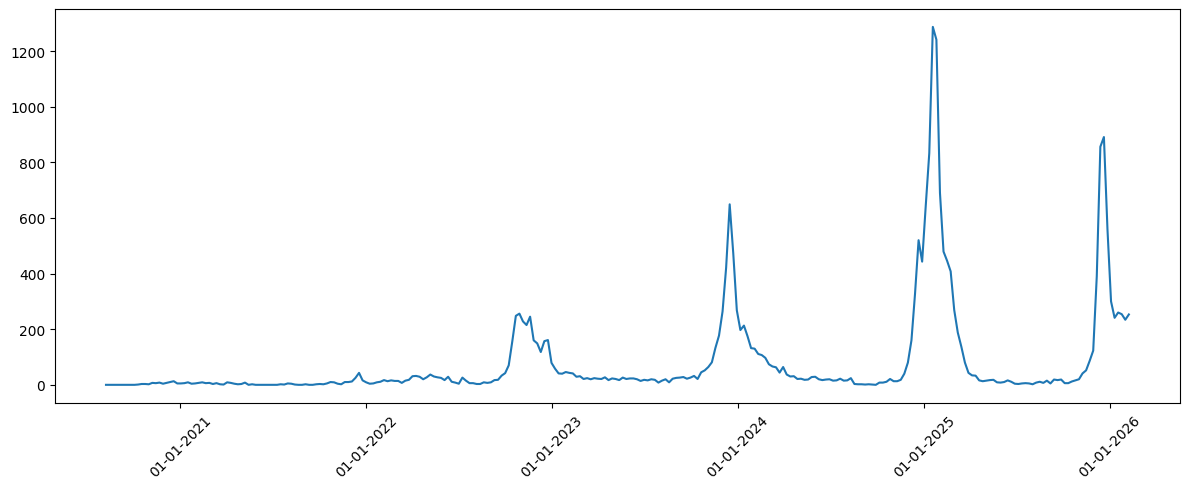

In [14]:
import matplotlib.dates as mdates

df_plot = vif_df_before_feature_engineering.copy()
df_plot['Week'] = pd.to_datetime(df_plot['Week'])

plt.figure(figsize=(12, 5))
plt.plot(df_plot['Week'], df_plot["Total.Influenza.Admissions_CDC_T+2"])

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering

In [15]:
# -----------------------------
# Feature engineering for T+2 forecasting
# Assumes:
# - Total.Influenza.Admissions_CDC is the observed target at week t
# - Total.Influenza.Admissions_CDC_T+2 is the label for week t+2
# -----------------------------
df = vif_df_before_feature_engineering.copy()

print(df.shape)

time_col = "Week"
current_target_col = "Total.Influenza.Admissions_CDC"
label_col = "Total.Influenza.Admissions_CDC_T+2"
final_target_col = "Target_Shifhted"   # keep this name if downstream cells use it
n_lags = 3

# -----------------------------
# Sort by date
# -----------------------------
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# -----------------------------
# Optional safety check:
# confirm the existing T+2 label matches the sorted current target
# -----------------------------
expected_label = df[current_target_col].shift(-2)
label_ok = np.isclose(
    df[label_col].to_numpy(dtype=float),
    expected_label.to_numpy(dtype=float),
    equal_nan=True
).all()

if not label_ok:
    raise ValueError(
        f"{label_col} is not aligned with {current_target_col}.shift(-2) after sorting."
    )

# -----------------------------
# Seasonality
# -----------------------------
df["week_num"] = df[time_col].dt.isocalendar().week.astype(int)
df["sin_week"] = np.sin(2 * np.pi * df["week_num"] / 52)
df["cos_week"] = np.cos(2 * np.pi * df["week_num"] / 52)

season_cols = ["sin_week", "cos_week"]

# Raw exogenous features only
feature_cols = [
    c for c in df.columns
    if c not in [time_col, current_target_col, label_col, "week_num"] + season_cols
]

def safe_pct_change(curr, prev):
    out = (curr - prev) / prev
    out = out.where(prev.notna(), np.nan)
    out = out.mask(prev == 0, 0.0)
    return out

def safe_ratio(curr, prev):
    out = curr / prev
    out = out.where(prev.notna(), np.nan)
    out = out.mask(prev == 0, 1.0)
    return out

new_features = {}

# -----------------------------
# Exogenous feature engineering
# Use only week t and earlier
# -----------------------------
for col in feature_cols:
    s = df[col]

    for lag in range(1, n_lags + 1):
        new_features[f"{col}_lag{lag}"] = s.shift(lag)

    new_features[f"{col}_pct_change1"] = safe_pct_change(s, s.shift(1))
    new_features[f"{col}_pct_change2"] = safe_pct_change(s.shift(1), s.shift(2))
    new_features[f"{col}_ratio1"] = safe_ratio(s, s.shift(1))
    new_features[f"{col}_ratio2"] = safe_ratio(s.shift(1), s.shift(2))
    new_features[f"{col}_rollmean2"] = s.rolling(2).mean()
    new_features[f"{col}_rollmean4"] = s.rolling(4).mean()
    new_features[f"{col}_speed"] = s.diff()
    new_features[f"{col}_acc"] = s.diff().diff()

# -----------------------------
# Target-history engineering
# Use observed target at week t, not the T+2 label
# -----------------------------
y_hist = df[current_target_col]

new_features[current_target_col] = y_hist

for lag in range(1, n_lags + 1):
    new_features[f"{current_target_col}_lag{lag}"] = y_hist.shift(lag)

new_features[f"{current_target_col}_pct_change1"] = safe_pct_change(y_hist, y_hist.shift(1))
new_features[f"{current_target_col}_pct_change2"] = safe_pct_change(y_hist.shift(1), y_hist.shift(2))
new_features[f"{current_target_col}_ratio1"] = safe_ratio(y_hist, y_hist.shift(1))
new_features[f"{current_target_col}_ratio2"] = safe_ratio(y_hist.shift(1), y_hist.shift(2))
new_features[f"{current_target_col}_rollmean2"] = y_hist.rolling(2).mean()
new_features[f"{current_target_col}_rollmean4"] = y_hist.rolling(4).mean()
new_features[f"{current_target_col}_speed"] = y_hist.diff()
new_features[f"{current_target_col}_acc"] = y_hist.diff().diff()

features_df = pd.DataFrame(new_features, index=df.index)

# -----------------------------
# Final modeling frame
# -----------------------------
df_full = pd.concat(
    [df[[time_col] + feature_cols + season_cols], features_df],
    axis=1
)

df_full[final_target_col] = df[label_col]

model_feature_cols = [
    c for c in df_full.columns
    if c not in [time_col, final_target_col]
]

# Training data: complete features + known T+2 label
vif_df_after_feature_engineering = df_full.dropna(
    subset=model_feature_cols + [final_target_col]
).reset_index(drop=True)

# Forecast row: latest week with complete features, label not required
df_for_forecast = df_full.dropna(
    subset=model_feature_cols
).tail(1).reset_index(drop=True)

print("Before feature engineering:", df.shape)
print("After feature engineering:", vif_df_after_feature_engineering.shape)
print("Forecast row shape:", df_for_forecast.shape)
print("Forecast week:", df_for_forecast[time_col].iloc[0])

vif_df_after_feature_engineering.tail()


(290, 21)
Before feature engineering: (290, 24)
After feature engineering: (285, 232)
Forecast row shape: (1, 232)
Forecast week: 2026-02-21 00:00:00


,Week,Weekly_Encounters_PRISMA,Weekly_Diagnoses_PRISMA,Weekly_Positive_Tests_PRISMA,Weekly_Encounters_MUSC,Weekly_Diagnoses_MUSC,Weekly_Positive_Tests_MUSC,Weekly_Outpatient_MUSC,Weekly_Inpatient_Hospitalizations_PRISMA,Cumulative_Vaccines_MUSC,...,Total.Influenza.Admissions_CDC_lag3,Total.Influenza.Admissions_CDC_pct_change1,Total.Influenza.Admissions_CDC_pct_change2,Total.Influenza.Admissions_CDC_ratio1,Total.Influenza.Admissions_CDC_ratio2,Total.Influenza.Admissions_CDC_rollmean2,Total.Influenza.Admissions_CDC_rollmean4,Total.Influenza.Admissions_CDC_speed,Total.Influenza.Admissions_CDC_acc,Target_Shifhted
280,2026-01-10,1902.0,1732.0,1605.0,996.0,891.0,602.0,434.0,143.0,1467406.0,...,391.0,-0.372615,0.040888,0.627385,1.040888,725.0,674.25,-332.0,-367.0,241.0
281,2026-01-17,1080.0,981.0,916.0,658.0,586.0,380.0,353.0,65.0,1468106.0,...,856.0,-0.463327,-0.372615,0.536673,0.627385,429.5,651.50,-259.0,73.0,260.0
282,2026-01-24,1433.0,1282.0,1260.0,942.0,846.0,594.0,488.0,60.0,1468496.0,...,891.0,-0.196667,-0.463327,0.803333,0.536673,270.5,497.75,-59.0,200.0,254.0
283,2026-01-31,1149.0,1045.0,1029.0,989.0,905.0,614.0,541.0,73.0,1468868.0,...,559.0,0.078838,-0.196667,1.078838,0.803333,250.5,340.00,19.0,78.0,234.0
284,2026-02-07,1076.0,964.0,960.0,1073.0,972.0,724.0,607.0,70.0,1469149.0,...,300.0,-0.023077,0.078838,0.976923,1.078838,257.0,263.75,-6.0,-25.0,253.0


## Feature Selection using MI after feature engineering

In [16]:
'''
from sklearn.feature_selection import mutual_info_regression

target_col = "Target_Shifhted"

df_mi = df_for_training.copy()
df_mi["Week"] = pd.to_datetime(df_mi["Week"], errors="coerce")
df_mi = df_mi.sort_values("Week").reset_index(drop=True)

# Remove rows where shifted target is missing
df_mi = df_mi.dropna(subset=[target_col]).reset_index(drop=True)

# Chronological split
test_fraction = 0.10
split_idx = int(len(df_mi) * (1 - test_fraction))

train_mi = df_mi.iloc[:split_idx].copy()
test_mi = df_mi.iloc[split_idx:].copy()

# MI on training set only
train_numeric = train_mi.select_dtypes(include=[np.number]).copy()
train_numeric = train_numeric.dropna(axis=1, how="all")
train_numeric = train_numeric.dropna(subset=[target_col]).reset_index(drop=True)

X_train = train_numeric.drop(columns=[target_col])
y_train = train_numeric[target_col]

# Fill feature gaps using training-only medians.
X_train = X_train.fillna(X_train.median())

mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

mi_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "MI_Score": mi_scores
    })
    .sort_values("MI_Score", ascending=False)
    .reset_index(drop=True)
)

mi_df.head(30)
'''


'\nfrom sklearn.feature_selection import mutual_info_regression\n\ntarget_col = "Target_Shifhted"\n\ndf_mi = df_for_training.copy()\ndf_mi["Week"] = pd.to_datetime(df_mi["Week"], errors="coerce")\ndf_mi = df_mi.sort_values("Week").reset_index(drop=True)\n\n# Remove rows where shifted target is missing\ndf_mi = df_mi.dropna(subset=[target_col]).reset_index(drop=True)\n\n# Chronological split\ntest_fraction = 0.10\nsplit_idx = int(len(df_mi) * (1 - test_fraction))\n\ntrain_mi = df_mi.iloc[:split_idx].copy()\ntest_mi = df_mi.iloc[split_idx:].copy()\n\n# MI on training set only\ntrain_numeric = train_mi.select_dtypes(include=[np.number]).copy()\ntrain_numeric = train_numeric.dropna(axis=1, how="all")\ntrain_numeric = train_numeric.dropna(subset=[target_col]).reset_index(drop=True)\n\nX_train = train_numeric.drop(columns=[target_col])\ny_train = train_numeric[target_col]\n\n# Fill feature gaps using training-only medians.\nX_train = X_train.fillna(X_train.median())\n\nmi_scores = mutual_inf

In [17]:
"""
# Taking the necessary columns only
#'Weekly_Tests_PRISMA','Weekly_Tests_PRISMA','Weekly_Positive_Tests_PRISMA'
## Add the week column as the first column

# Top 30 MI features
top_30_features = mi_df["Feature"].head(30).tolist()
top_30_features = [c for c in top_30_features if c in df_for_training.columns and c != target_col]

# Final column order: Week first, then top MI features, then target
final_columns = ["Week"] + top_30_features + [target_col]
final_columns = list(dict.fromkeys(final_columns))

# Keep train/test modeling data and forecast data on the same selected feature set.
df_for_training = df_for_training[final_columns].copy()
df_for_forecast = df_for_forecast[["Week"] + top_30_features].copy()

df_for_training.tail()
"""


'\n# Taking the necessary columns only\n#\'Weekly_Tests_PRISMA\',\'Weekly_Tests_PRISMA\',\'Weekly_Positive_Tests_PRISMA\'\n## Add the week column as the first column\n\n# Top 30 MI features\ntop_30_features = mi_df["Feature"].head(30).tolist()\ntop_30_features = [c for c in top_30_features if c in df_for_training.columns and c != target_col]\n\n# Final column order: Week first, then top MI features, then target\nfinal_columns = ["Week"] + top_30_features + [target_col]\nfinal_columns = list(dict.fromkeys(final_columns))\n\n# Keep train/test modeling data and forecast data on the same selected feature set.\ndf_for_training = df_for_training[final_columns].copy()\ndf_for_forecast = df_for_forecast[["Week"] + top_30_features].copy()\n\ndf_for_training.tail()\n'

In [18]:
# Forecast row: latest available row, no future target needed
#forecast_feature_cols = [c for c in df_merged.columns if c != "Target_Shifhted"]
#df_for_forecast = df_merged[forecast_feature_cols].dropna().tail(1).reset_index(drop=True)
#print("Forecast row shape:", df_for_forecast.shape)
#df_for_forecast



## Model

In [19]:
# -----------------------------
# Separating Target column and Feature Column
# -----------------------------

target_col = "Target_Shifhted"
time_col = 'Week'

vif_df_after_feature_engineering["Week"] = pd.to_datetime(vif_df_after_feature_engineering["Week"])
vif_df_after_feature_engineering= vif_df_after_feature_engineering.sort_values(time_col).reset_index(drop=True)

feature_cols = [
    c for c in vif_df_after_feature_engineering.columns
    if c not in ["Week", target_col]
]

In [29]:
# -----------------------------
# Train / Test split
# -----------------------------
test_fraction = 0.05
forecast_horizon = 2
split_idx = int(len(vif_df_after_feature_engineering) * (1 - test_fraction))
train_end_idx = split_idx - forecast_horizon

if train_end_idx <= 0:
    raise ValueError("Not enough rows to create a leakage-safe hold-out split.")

train_df = vif_df_after_feature_engineering.iloc[:train_end_idx].copy()
gap_df = vif_df_after_feature_engineering.iloc[train_end_idx:split_idx].copy()
test_df = vif_df_after_feature_engineering.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df["Target_Shifhted"]

X_test = test_df[feature_cols]
y_test = test_df["Target_Shifhted"]

# TimeSeries CV uses only training data.
X = X_train
y = y_train

print("Train size:", X.shape)
print("Gap size:", gap_df.shape)
print("Test size:", X_test.shape)


Train size: (268, 230)
Gap size: (2, 232)
Test size: (15, 230)


In [30]:
X.tail()

,Weekly_Encounters_PRISMA,Weekly_Diagnoses_PRISMA,Weekly_Positive_Tests_PRISMA,Weekly_Encounters_MUSC,Weekly_Diagnoses_MUSC,Weekly_Positive_Tests_MUSC,Weekly_Outpatient_MUSC,Weekly_Inpatient_Hospitalizations_PRISMA,Cumulative_Vaccines_MUSC,Weekly_Tests_PRISMA,...,Total.Influenza.Admissions_CDC_lag2,Total.Influenza.Admissions_CDC_lag3,Total.Influenza.Admissions_CDC_pct_change1,Total.Influenza.Admissions_CDC_pct_change2,Total.Influenza.Admissions_CDC_ratio1,Total.Influenza.Admissions_CDC_ratio2,Total.Influenza.Admissions_CDC_rollmean2,Total.Influenza.Admissions_CDC_rollmean4,Total.Influenza.Admissions_CDC_speed,Total.Influenza.Admissions_CDC_acc
263,54.0,44.0,35.0,42.0,39.0,14.0,25.0,7.0,1418252.0,4724.0,...,11.0,8.0,1.142857,-0.363636,2.142857,0.636364,11.0,10.25,8.0,12.0
264,41.0,33.0,34.0,39.0,35.0,17.0,27.0,2.0,1419963.0,4268.0,...,7.0,11.0,-0.666667,1.142857,0.333333,2.142857,10.0,9.50,-10.0,-18.0
265,50.0,39.0,40.0,32.0,27.0,18.0,18.0,9.0,1421866.0,4325.0,...,15.0,7.0,2.800000,-0.666667,3.800000,0.333333,12.0,11.50,14.0,24.0
266,38.0,30.0,28.0,39.0,34.0,20.0,23.0,3.0,1425294.0,4128.0,...,5.0,15.0,-0.105263,2.800000,0.894737,3.800000,18.0,14.00,-2.0,-16.0
267,40.0,36.0,27.0,30.0,28.0,9.0,20.0,4.0,1429583.0,4070.0,...,19.0,5.0,0.117647,-0.105263,1.117647,0.894737,18.0,15.00,2.0,4.0


In [31]:
y.tail()

263    19.0
264    17.0
265    19.0
266     6.0
267     6.0
Name: Target_Shifhted, dtype: float64

In [32]:
## Defining PERCENT AGREEMENT
######################################################
from sklearn.metrics import mean_absolute_error

def percent_agreement_fraction(y_true, y_pred, small_threshold=15):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    ignore = (y_true < small_threshold)
    use = ~ignore

    yt = y_true[use]
    yp = y_pred[use]

    used = int(yt.size)
    ignored = int(ignore.sum())

    if used == 0:
        return {"score": np.nan, "used": used, "ignored": ignored}

    denom = np.maximum(yt, yp)
    score = np.divide(np.minimum(yt, yp), denom, out=np.zeros_like(denom), where=denom != 0)
    return {"score": float(np.mean(score)), "used": used, "ignored": ignored}


In [33]:
from sklearn.model_selection import TimeSeriesSplit

SEED = 42
forecast_horizon = 2
tscv = TimeSeriesSplit(n_splits=10, gap=2)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "n_jobs": 1,
        "verbosity": 0,
        "random_state": SEED,
    }

    oof_preds = np.full(len(X), np.nan, dtype=float)
    y_true = y.to_numpy(dtype=float)

    for train_idx, val_idx in tscv.split(X):
        model = XGBRegressor(**params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx], verbose=False)
        preds = model.predict(X.iloc[val_idx])
        preds = np.maximum(preds, 1)   # avoid negative predictions
        oof_preds[val_idx] = preds

    valid_mask = ~np.isnan(oof_preds)
    pa = percent_agreement_fraction(
        y_true[valid_mask],
        oof_preds[valid_mask],
        small_threshold=15
    )["score"]

    return pa

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=25)

print("Best parameters:", study.best_params)
print("Best PA:", study.best_value)


[I 2026-04-28 22:45:08,305] A new study created in memory with name: no-name-4f41bda6-e373-4912-8689-8b40f345a578
[I 2026-04-28 22:45:42,896] Trial 0 finished with value: 0.6499956079634278 and parameters: {'n_estimators': 425, 'max_depth': 8, 'learning_rate': 0.07587945476302646, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.05808361216819946, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.6499956079634278.
[I 2026-04-28 22:46:05,737] Trial 1 finished with value: 0.6388705494260337 and parameters: {'n_estimators': 625, 'max_depth': 3, 'learning_rate': 0.0972918866945795, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.18340450985343382, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 2.6237821581611893}. Best is trial 0 with value: 0.6499956079634278.
[I 2026-04-28 22:46:31,909] Trial 2 finished with value: 0.621109781

Best parameters: {'n_estimators': 537, 'max_depth': 7, 'learning_rate': 0.0665720124616234, 'subsample': 0.8282591385773285, 'colsample_bytree': 0.7068054465767163, 'min_child_weight': 1, 'gamma': 0.895588835588778, 'reg_alpha': 0.7405590515033794, 'reg_lambda': 3.7554412549120637}
Best PA: 0.6553087600866363


In [34]:
## Training the model using all Training data and the best hyperparams
best_params = study.best_params.copy()
best_params.update({
    ###########################################################################
   # "random_state": SEED,
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "n_jobs": 1,
    "verbosity": 0,
})

final_model_test = XGBRegressor(**best_params)
final_model_test.fit(X_train, y_train, verbose=False)

test_preds = final_model_test.predict(X_test)

test_mae = mean_absolute_error(y_test, test_preds)
test_PA = percent_agreement_fraction(y_test, test_preds, 15)

print("Hold-out Test MAE:", test_mae)
print("Hold-out Test PA:", test_PA)

Hold-out Test MAE: 110.07101033528646
Hold-out Test PA: {'score': 0.7240287661252494, 'used': 15, 'ignored': 0}


Hold-out Test MAE: 110.07101033528646
Hold-out Test PA: {'score': 0.7240287661252494, 'used': 15, 'ignored': 0}
         Week  actual   predicted
0  2025-11-01    20.0   35.807526
1  2025-11-08    41.0   58.604511
2  2025-11-15    52.0   54.190815
3  2025-11-22    86.0   85.154709
4  2025-11-29   123.0   65.430504
5  2025-12-06   391.0  146.156189
6  2025-12-13   856.0  216.917435
7  2025-12-20   891.0  633.403381
8  2025-12-27   559.0  547.073425
9  2026-01-03   300.0  425.447174
10 2026-01-10   241.0  316.471100
11 2026-01-17   260.0  245.141525
12 2026-01-24   254.0  324.384094
13 2026-01-31   234.0  301.544617
14 2026-02-07   253.0  302.892487


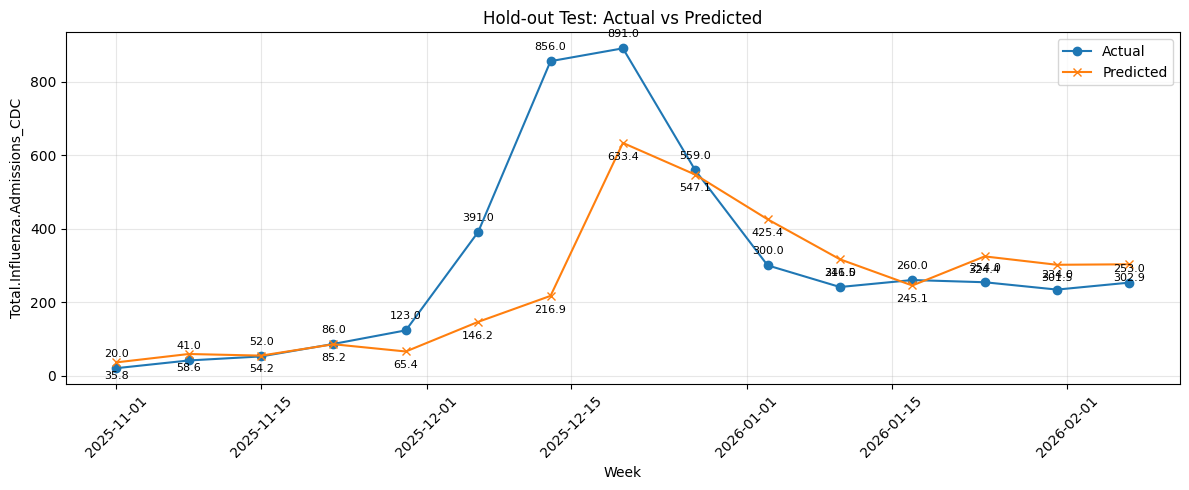

Diagnostic only: adjusted_predicted uses earlier hold-out actuals and is not leakage-free.
Adjusted MAE (all test points): 176.41053449620188
Adjusted PA  (all test points): {'score': 0.7352597294907512, 'used': 15, 'ignored': 0}
Adjusted MAE (excluding first point): 187.8821779863045
Adjusted PA  (excluding first point): {'score': 0.747882438384196, 'used': 14, 'ignored': 0}
         Week  actual   predicted  current_ratio  adjusted_predicted
0  2025-11-01    20.0   35.807526       0.558542           35.807526
1  2025-11-08    41.0   58.604511       0.699605           32.729796
2  2025-11-15    52.0   54.190815       0.959572           37.908365
3  2025-11-22    86.0   85.154709       1.009927           81.703921
4  2025-11-29   123.0   65.430504       1.879857           66.073394
5  2025-12-06   391.0  146.156189       2.675220          274.725280
6  2025-12-13   856.0  216.917435       3.946202          580.243889
7  2025-12-20   891.0  633.403381       1.406687         2499.287694


C:\Users\Gaurob\AppData\Local\Temp\ipykernel_13760\338096359.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '32.72979619287999' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  adjusted_df.loc[i, "adjusted_predicted"] = (


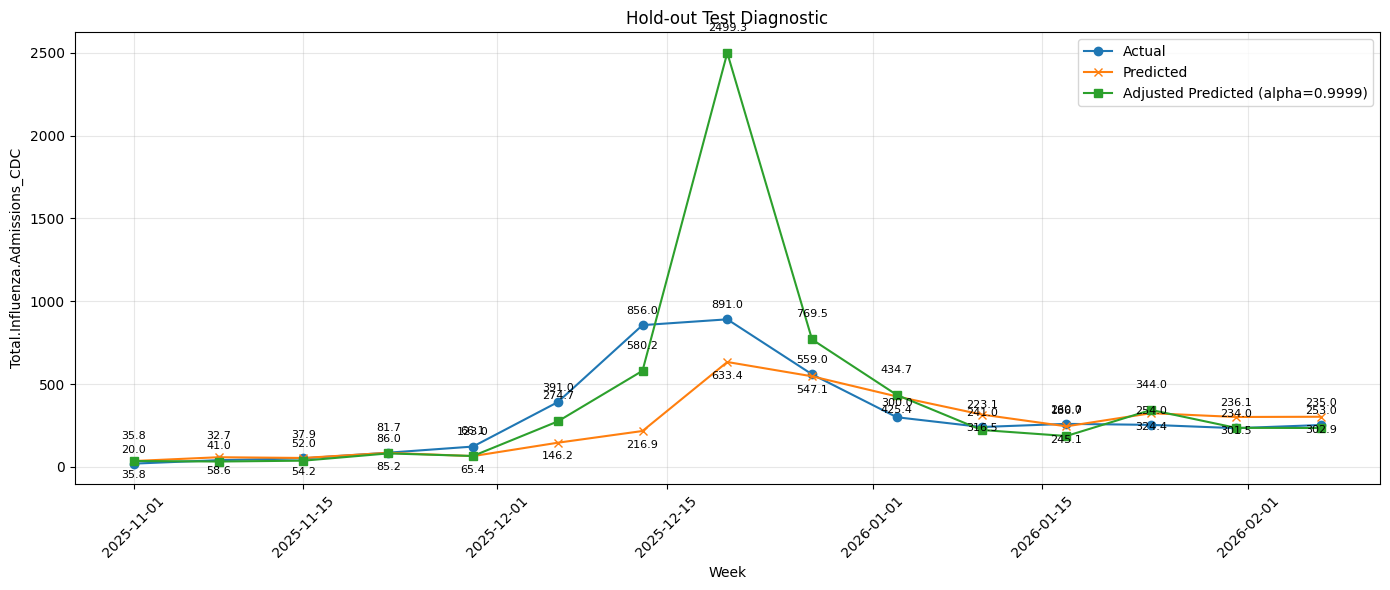

In [37]:
# -----------------------------
# Hold-out test: print and plot
# -----------------------------
test_preds = np.maximum(np.asarray(test_preds).ravel(), 1)

comparison_test = pd.DataFrame({
    time_col: pd.to_datetime(test_df[time_col]).reset_index(drop=True),
    "actual": y_test.reset_index(drop=True).to_numpy(),
    "predicted": test_preds
})

test_mae = mean_absolute_error(comparison_test["actual"], comparison_test["predicted"])
test_PA = percent_agreement_fraction(comparison_test["actual"], comparison_test["predicted"], 15)

print("Hold-out Test MAE:", test_mae)
print("Hold-out Test PA:", test_PA)
print(comparison_test)

plt.figure(figsize=(12, 5))
plt.plot(comparison_test[time_col], comparison_test["actual"], marker="o", label="Actual")
plt.plot(comparison_test[time_col], comparison_test["predicted"], marker="x", label="Predicted")

for x, y in zip(comparison_test[time_col], comparison_test["actual"]):
    plt.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

for x, y in zip(comparison_test[time_col], comparison_test["predicted"]):
    plt.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, -12), ha="center", fontsize=8)

plt.title("Hold-out Test: Actual vs Predicted")
plt.xlabel(time_col)
plt.ylabel("Total.Influenza.Admissions_CDC")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Do not recalibrate later hold-out predictions using earlier hold-out actuals.
# For T+h forecasting, that would leak information across the evaluation window.

print("Diagnostic only: adjusted_predicted uses earlier hold-out actuals and is not leakage-free.")

def adjust_and_plot_test(comparison_df, alpha=0.99, pa_threshold=15, title="Hold-out Test Diagnostic"):
    adjusted_df = comparison_df.copy()

    adjusted_df["current_ratio"] = 1.0
    nonzero_mask = adjusted_df["predicted"] != 0
    adjusted_df.loc[nonzero_mask, "current_ratio"] = (
        adjusted_df.loc[nonzero_mask, "actual"] / adjusted_df.loc[nonzero_mask, "predicted"]
    )

    adjusted_df["adjusted_predicted"] = adjusted_df["predicted"].copy()

    for i in range(1, len(adjusted_df)):
        adjusted_df.loc[i, "adjusted_predicted"] = (
            adjusted_df.loc[i, "predicted"]
            * adjusted_df.loc[i - 1, "current_ratio"]
            * alpha
        )

    adjusted_mae_all = mean_absolute_error(adjusted_df["actual"], adjusted_df["adjusted_predicted"])
    adjusted_PA_all = percent_agreement_fraction(
        adjusted_df["actual"], adjusted_df["adjusted_predicted"], pa_threshold
    )

    if len(adjusted_df) > 1:
        adjusted_mae_excl_first = mean_absolute_error(
            adjusted_df["actual"].iloc[1:],
            adjusted_df["adjusted_predicted"].iloc[1:]
        )
        adjusted_PA_excl_first = percent_agreement_fraction(
            adjusted_df["actual"].iloc[1:],
            adjusted_df["adjusted_predicted"].iloc[1:],
            pa_threshold
        )
    else:
        adjusted_mae_excl_first = np.nan
        adjusted_PA_excl_first = np.nan

    print("Adjusted MAE (all test points):", adjusted_mae_all)
    print("Adjusted PA  (all test points):", adjusted_PA_all)
    print("Adjusted MAE (excluding first point):", adjusted_mae_excl_first)
    print("Adjusted PA  (excluding first point):", adjusted_PA_excl_first)
    print(adjusted_df)

    plt.figure(figsize=(14, 6))
    plt.plot(adjusted_df[time_col], adjusted_df["actual"], marker="o", label="Actual")
    plt.plot(adjusted_df[time_col], adjusted_df["predicted"], marker="x", label="Predicted")
    plt.plot(
        adjusted_df[time_col],
        adjusted_df["adjusted_predicted"],
        marker="s",
        label=f"Adjusted Predicted (alpha={alpha})"
    )

    for x, y in zip(adjusted_df[time_col], adjusted_df["actual"]):
        plt.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

    for x, y in zip(adjusted_df[time_col], adjusted_df["predicted"]):
        plt.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, -12), ha="center", fontsize=8)

    for x, y in zip(adjusted_df[time_col], adjusted_df["adjusted_predicted"]):
        plt.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 16), ha="center", fontsize=8)

    plt.title(title)
    plt.xlabel(time_col)
    plt.ylabel("Total.Influenza.Admissions_CDC")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    last_current_ratio = adjusted_df["current_ratio"].iloc[-1]
    return adjusted_df, last_current_ratio


adjusted_test_df, last_ratio_test = adjust_and_plot_test(
    comparison_test,
    alpha=0.9999,
    pa_threshold=15,
    title="Hold-out Test Diagnostic"
)
